### Hybrid Movie Recommendation System Using Content-Based Filtering with Deep Learning

**Dataset Link - https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata**

#### Importing Libraries

In [60]:
import kaggle
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
import pickle

#### Dataset Download

In [61]:
kaggle.api.authenticate()
kaggle.api.dataset_download_files('tmdb/tmdb-movie-metadata', path="datasets", unzip=True)
print("Dataset Downloaded")

Dataset URL: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
Dataset Downloaded


#### Merging Datasets

In [62]:
movies = pd.read_csv("datasets/tmdb_5000_movies.csv")
credits = pd.read_csv("datasets/tmdb_5000_credits.csv")
movies = movies.merge(credits, on='title')

#### Visualization

In [63]:
os.makedirs("plots", exist_ok=True)

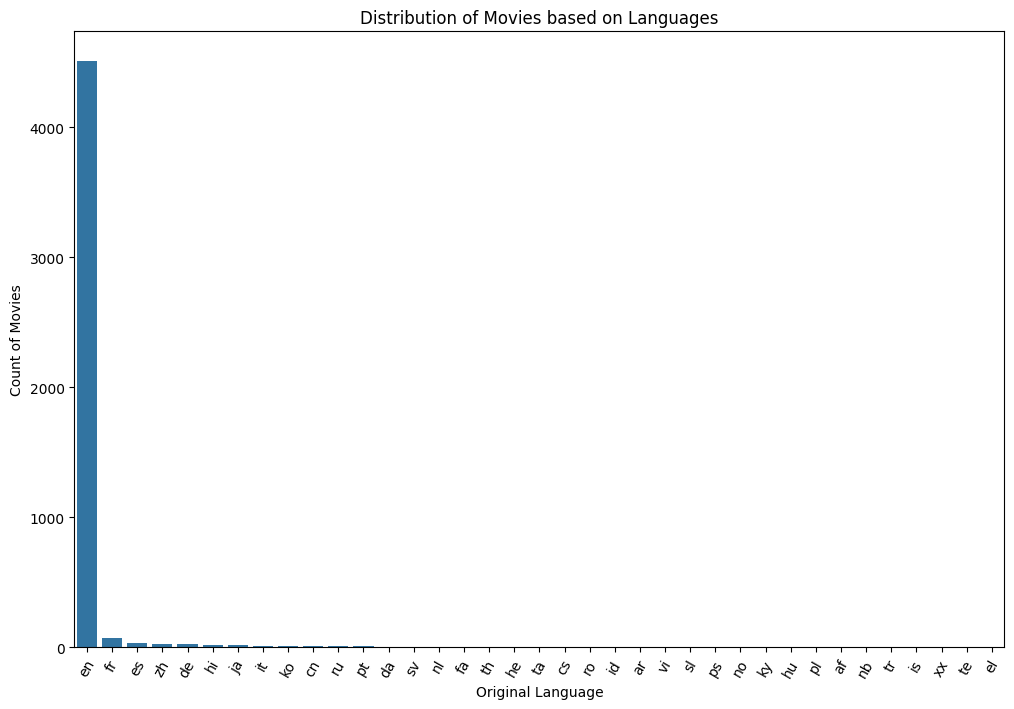

In [64]:
plt.figure(figsize=(12, 8))
sns.barplot(x=movies['original_language'].value_counts().index.to_list(), 
            y=movies['original_language'].value_counts().values.tolist())
plt.xlabel("Original Language")
plt.ylabel('Count of Movies')
plt.xticks(rotation=60)
plt.title("Distribution of Movies based on Languages")
plt.savefig("./plots/1_img.png")
plt.show()

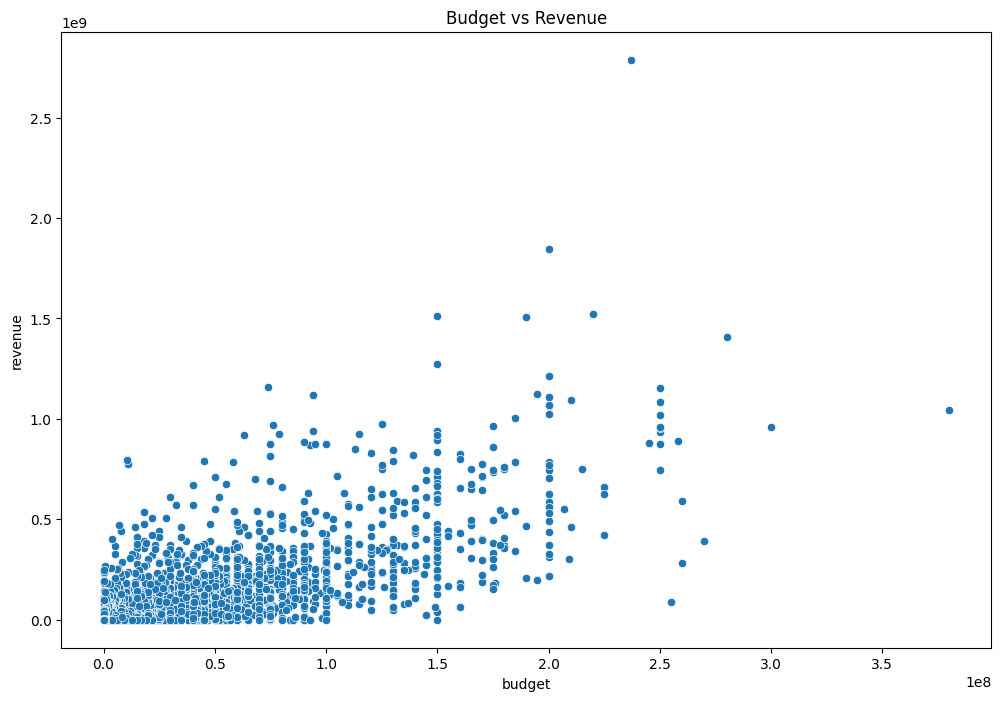

In [65]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=movies, x='budget', y='revenue')
plt.title("Budget vs Revenue")
plt.savefig("./plots/2_img.png")
plt.show()

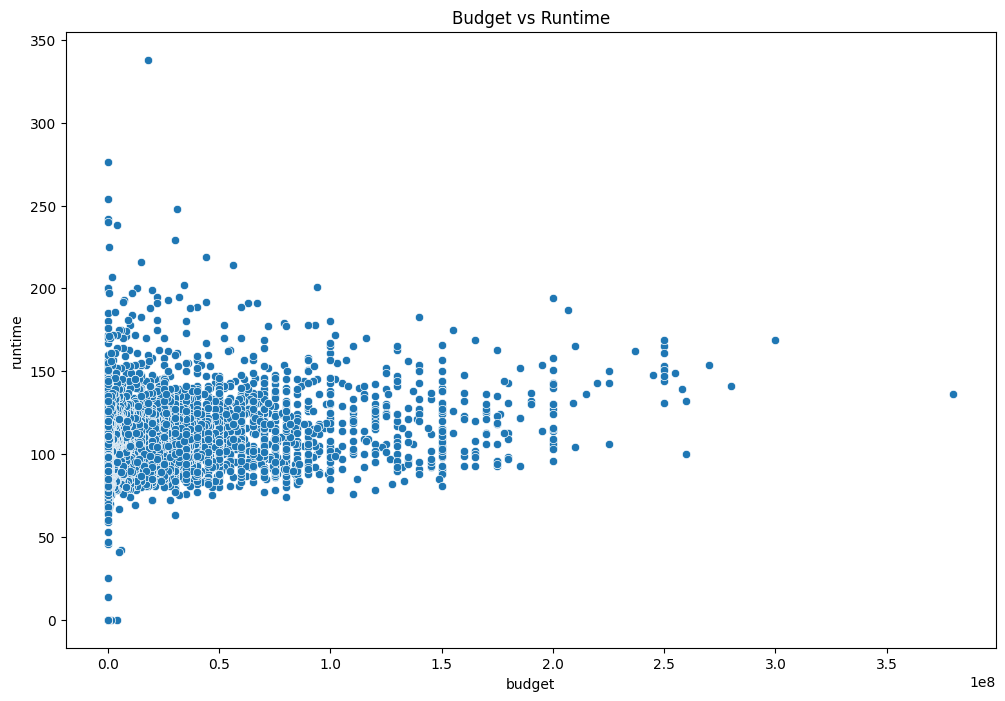

In [66]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=movies, x='budget', y='runtime')
plt.title("Budget vs Runtime")
plt.savefig("./plots/3_img.png")
plt.show()

#### Preprocessing

In [67]:
movies['release_date'] = pd.to_datetime(movies['release_date']).bfill()
movies['year'] = pd.to_numeric(movies['release_date'].dt.year, errors='coerce')
movies.dropna(subset=['year'], inplace=True)
bins = range(int(movies['year'].min()), int(movies['year'].max()) + 10, 10)
movies['year_bin'] = pd.cut(movies['year'], bins=bins)
year_bin_counts = movies['year_bin'].value_counts().sort_index()

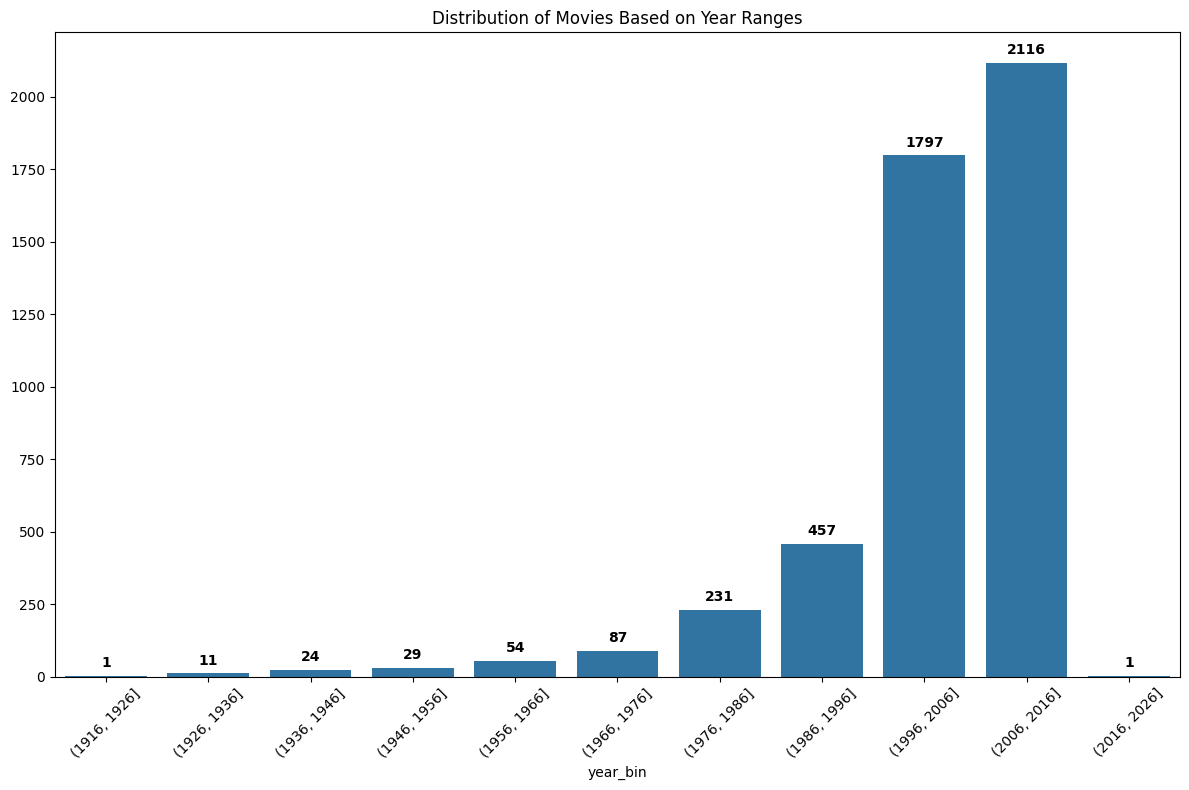

In [68]:
plt.figure(figsize=(12, 8))
ax = sns.barplot(x=year_bin_counts.index.astype(str), y=year_bin_counts.values)
for bar, count in zip(ax.patches, year_bin_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(count),
            ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title("Distribution of Movies Based on Year Ranges")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("./plots/4_img.png")
plt.show()

#### Important Columns

In [69]:
movies = movies[['movie_id', 'title', 'overview', 'genres', 'keywords', 'cast', 'crew']]
movies.dropna(inplace=True)

#### Custom Functions

In [70]:
def convert(text):
    return [i['name'] for i in ast.literal_eval(text)]

In [71]:
def convert3(text):
    return [i['name'] for i in ast.literal_eval(text)[:3]]

In [72]:
def fetch_director(text):
    return [i['name'] for i in ast.literal_eval(text) if i['job'] == 'Director']

In [73]:
def collapse(L):
    return [i.replace(" ", "") for i in L]

#### Applying Functions

In [74]:
movies['genres'] = movies['genres'].apply(convert).apply(collapse)
movies['keywords'] = movies['keywords'].apply(convert).apply(collapse)
movies['cast'] = movies['cast'].apply(convert3).apply(collapse)
movies['crew'] = movies['crew'].apply(fetch_director).apply(collapse)
movies['overview'] = movies['overview'].apply(lambda x: x.split())
movies['tags'] = movies['overview'] + movies['genres'] + movies['keywords'] + movies['cast'] + movies['crew']
new = movies.drop(columns=['overview', 'genres', 'keywords', 'cast', 'crew'])
new['tags'] = new['tags'].apply(lambda x: " ".join(x))

#### Models

**CountVectorizer + Cosine Similarity (Content-based)**

In [75]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vector = cv.fit_transform(new['tags']).toarray().astype('float32')
similarity = cosine_similarity(vector)

**TF-IDF + Cosine Similarity**

In [76]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_vector = tfidf.fit_transform(new['tags']).toarray().astype('float32')
tfidf_similarity = cosine_similarity(tfidf_vector)

**Word2Vec + Cosine Similarity**

In [77]:
corpus = [doc.split() for doc in new['tags']]
w2v_model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1)
def document_vector(doc):
    words = doc.split()
    word_vecs = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    return np.mean(word_vecs, axis=0) if word_vecs else np.zeros(100)
w2v_vectors = np.array([document_vector(text) for text in new['tags']])
w2v_similarity = cosine_similarity(w2v_vectors)

**Sentence BERT**

In [78]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Load a pretrained SBERT model
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')  # Lightweight and fast

# Generate sentence embeddings from 'tags'
sbert_embeddings = sbert_model.encode(new['tags'].tolist(), show_progress_bar=True)

# Compute cosine similarity
sbert_similarity = cosine_similarity(sbert_embeddings)

Batches: 100%|██████████| 151/151 [01:59<00:00,  1.26it/s]


#### Recommendation Function

**CountVectorizer**

In [79]:
def recommend(movie):
    index = new[new['title'] == movie].index[0]
    distances = sorted(list(enumerate(similarity[index])), reverse=True, key=lambda x: x[1])
    print("\nCountVectorizer Recommendations:")
    for i in distances[1:6]:
        print(new.iloc[i[0]].title)

**TF-IDF**

In [80]:
def recommend_tfidf(movie):
    index = new[new['title'] == movie].index[0]
    distances = sorted(list(enumerate(tfidf_similarity[index])), reverse=True, key=lambda x: x[1])
    print("\nTF-IDF Recommendations:")
    for i in distances[1:6]:
        print(new.iloc[i[0]].title)

**Word2Vec**

In [81]:
def recommend_w2v(movie):
    index = new[new['title'] == movie].index[0]
    distances = sorted(list(enumerate(w2v_similarity[index])), reverse=True, key=lambda x: x[1])
    print("\nWord2Vec Recommendations:")
    for i in distances[1:6]:
        print(new.iloc[i[0]].title)

**SBERT**

In [82]:
def recommend_sbert(movie):
    index = new[new['title'] == movie].index[0]
    distances = sorted(list(enumerate(sbert_similarity[index])), reverse=True, key=lambda x: x[1])
    print("\nSBERT Recommendations:")
    for i in distances[1:6]:
        print(new.iloc[i[0]].title)

#### Evaluation Metrics

In [83]:
def get_precision_recall(movie, sim_matrix, k=5):
    index = new[new['title'] == movie].index[0]
    actual_tags = set(new.iloc[index]['tags'].split())
    distances = sorted(list(enumerate(sim_matrix[index])), reverse=True, key=lambda x: x[1])
    recommended_indices = [i[0] for i in distances[1:k+1]]
    
    precision_list = []
    recall_list = []
    for idx in recommended_indices:
        predicted_tags = set(new.iloc[idx]['tags'].split())
        intersection = actual_tags.intersection(predicted_tags)
        precision = len(intersection) / len(predicted_tags) if predicted_tags else 0
        recall = len(intersection) / len(actual_tags) if actual_tags else 0
        precision_list.append(precision)
        recall_list.append(recall)
        
    return np.mean(precision_list), np.mean(recall_list)

In [84]:
movie_to_test = 'The Dark Knight'
precision_scores = {}
recall_scores = {}

In [85]:
p1, r1 = get_precision_recall(movie_to_test, similarity)
p2, r2 = get_precision_recall(movie_to_test, tfidf_similarity)
p3, r3 = get_precision_recall(movie_to_test, w2v_similarity)
p4, r4 = get_precision_recall(movie_to_test, sbert_similarity)

In [86]:
precision_scores['CountVectorizer'] = p1
precision_scores['TF-IDF'] = p2
precision_scores['Word2Vec'] = p3
precision_scores['SBERT'] = p4

In [87]:
recall_scores['CountVectorizer'] = r1
recall_scores['TF-IDF'] = r2
recall_scores['Word2Vec'] = r3
recall_scores['SBERT'] = r4

**Plotting Metrics**

C:\Users\Hi\AppData\Local\Temp\ipykernel_18904\2633924342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(precision_scores.keys()), y=list(precision_scores.values()), palette="Blues_d")


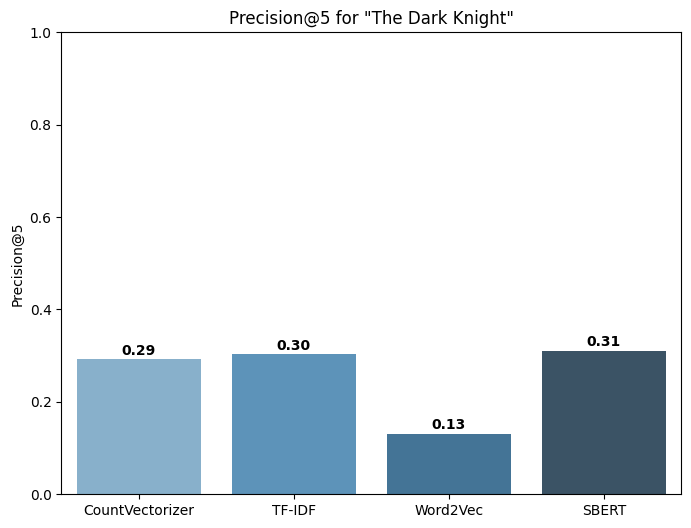

In [88]:
plt.figure(figsize=(8, 6))
sns.barplot(x=list(precision_scores.keys()), y=list(precision_scores.values()), palette="Blues_d")
plt.title(f'Precision@5 for "{movie_to_test}"')
plt.ylim(0, 1)
plt.ylabel('Precision@5')
for i, v in enumerate(precision_scores.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.savefig("./plots/5_img.png")
plt.show()

C:\Users\Hi\AppData\Local\Temp\ipykernel_18904\2156653921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(recall_scores.keys()), y=list(recall_scores.values()), palette="Greens_d")


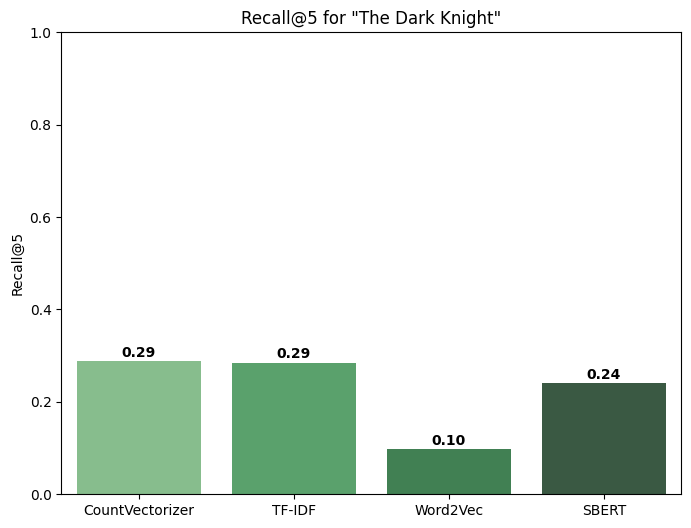

In [89]:
plt.figure(figsize=(8, 6))
sns.barplot(x=list(recall_scores.keys()), y=list(recall_scores.values()), palette="Greens_d")
plt.title(f'Recall@5 for "{movie_to_test}"')
plt.ylim(0, 1)
plt.ylabel('Recall@5')
for i, v in enumerate(recall_scores.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.savefig("./plots/6_img.png")
plt.show()

In [90]:
with open('movie_list.pkl', 'wb') as f:
    pickle.dump(new, f)

with open('model.pkl', 'wb') as f:
    pickle.dump(sbert_similarity, f)